<a href="https://colab.research.google.com/github/magagulamxolisi/Exchange-P/blob/main/FinBert_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets transformers venny4py yfinance -q

In [ ]:
from transformers import pipeline, set_seed

from datasets import load_dataset

import pandas as pd

import matplotlib.pyplot as plt

from venny4py.venny4py import venny4py

import yfinance as yf

import re

from datetime import datetime, timedelta

In [ ]:
from datasets import load_dataset

dataset = load_dataset("abisee/cnn_dailymail",dailymail)

README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

3.0.0/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  257MB            

3.0.0/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

3.0.0/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  257MB            

3.0.0/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

...

3.0.0/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 30.0MB            

3.0.0/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

In [ ]:
tesla_articles = dataset["train"].filter(
lambda example: "Tesla" in example["article"]
)
print("Number of Tesla articles:", len(tesla_articles))

Filter:   0%|          | 0/287113 [00:00<?, ? examples/s]

Number of Tesla articles: 171


In [ ]:
def text_classification(model_name, texts):

  pipe = pipeline(
      "text-classification",
      model=model_name
  )

  articles = [item["article"]for item in texts]

  results = []

  for article in articles:
    result = pipe(
        article,
        truncation=True,
        max_length=512
    )[10]


    results.append(result)






In [ ]:
tesla_sample = tesla_articles.select(range(10))

In [ ]:
tesla_sample = tesla_articles.select(range(20))

In [ ]:
results = []

for i in range(len(tesla_sample)):
  result = pipe(
      tesla_sample[i]["article"][:1000]
)
  results.append(result[0])

finbert_result = pd.DataFrame(results)

print(finbert_result["label"].value_counts())

label
neutral     17
positive     2
negative     1
Name: count, dtype: int64


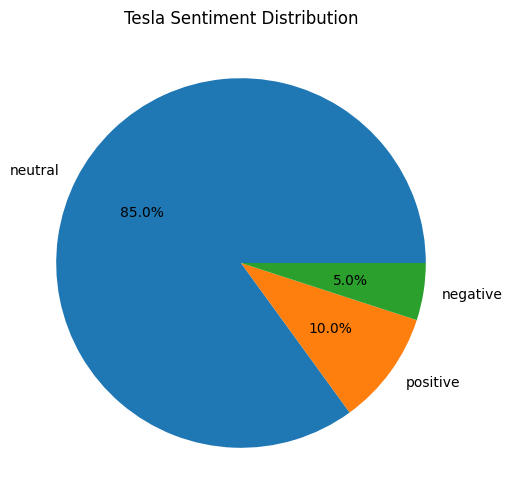

In [ ]:
finbert_result["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Tesla Sentiment Distribution")
plt.ylabel("")
plt.show()

In [2]:
import pandas as pd
from transformers import pipeline
def text_classification(model_name, texts):
  pipe = pipeline(
      "text-classification",
      model=model_name
)
  results = []
  for article in texts["article"]:
    result = pipe(
        article[:1000],
        truncation=True,
        max_length=512
)
    results.append(result[0])
    return pd.DataFrame(results)

In [ ]:
finbert_result.to_excel(
    "finbert_results.xlsx",
    index=False
)

In [ ]:
from google.colab import files

files.download("finbert_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
print(text_classification)

<function text_classification at 0x785df93be200>


In [ ]:
tesla_sample = tesla_articles.select(range(10))

In [ ]:
from transformers import pipeline, set_seed
import pandas as pd


In [ ]:
print(type(tesla_articles))

<class 'datasets.arrow_dataset.Dataset'>


In [ ]:
tesla_articles = tesla_articles.select(range(min(20, len(tesla_articles))))

In [ ]:
print(tesla_articles[0])

{'article': "LOS ANGELES, California (CNN)  -- While automakers lay off staff and shut down plants in response to the economic downturn, one automaker announced Thursday that it will open a manufacturing plant in the United States, potentially creating hundreds of jobs in the area eventually chosen. Tesla unveils its Model S sedan, with a base price of $57,400. The manufacturing plant will be in California. Tesla Motors, maker of a high-end electric sports car, says it will build an all-electric sedan in Southern California. Thursday's announcement was made in Hawthorne, California, where Tesla unveiled the Model S sedan at a base price of $49,900, after a federal tax credit of $7,500. That's less than half the price of its first model, the Roadster. Started in 2003 and bankrolled by PayPal millionaire Elon Musk, Tesla has attracted investments from the Silicon Valley elite, among them Google founder Larry Page. It is widely believed that the Model S sedan will be built near the Space 

In [ ]:
from transformers import pipeline

pipe = pipeline(
    "text-classification",
    model="ProsusAI/finbert"
)

result = pipe(tesla_articles[0]["article"])

print(result)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'negative', 'score': 0.8088356852531433}]


In [ ]:
finbert_result = text_classification(
    "ProsusAI/finbert",
    tesla_sample
)

print(finbert_result,head())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

IndexError: list index out of range

In [ ]:
tesla_sample = tesla_articles.select(range(3))

In [ ]:
from transformers import pipeline

pipe = pipeline(
    "text-classification",
    model="ProsusAI/finbert"
)

for i in range(3):
  print(f"\nArticle {i}")
  result = pipe(
      tesla_sample[i]["article"][:1000]

  )
  print(result)



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Article 0
[{'label': 'neutral', 'score': 0.8466703295707703}]

Article 1
[{'label': 'neutral', 'score': 0.9076032042503357}]

Article 2
[{'label': 'neutral', 'score': 0.9319790005683899}]


In [ ]:
results = []

for i in range(3):
  result = pipe(
      tesla_sample[i]["article"][:1000]
  )
  results.append(result[0])

finbert_result = pd.DataFrame(results)

print(finbert_result)

     label     score
0  neutral  0.846670
1  neutral  0.907603
2  neutral  0.931979


In [ ]:
print(finbert_result)

     label     score
0  neutral  0.846670
1  neutral  0.907603
2  neutral  0.931979


In [ ]:
print(finbert_result["label"].value_counts())

label
neutral    3
Name: count, dtype: int64


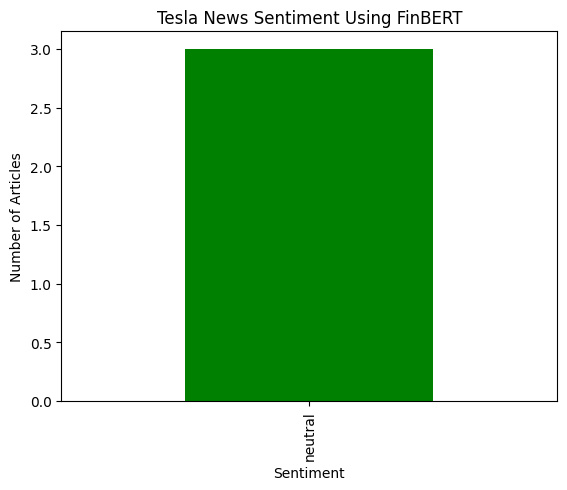

In [ ]:
import matplotlib.pyplot as plt

finbert_result["label"].value_counts().plot(
    kind="bar",
    color=["green", "grey", "red"]
)

plt.title("Tesla News Sentiment Using FinBERT")
plt.xlabel("Sentiment")
plt.ylabel("Number of Articles")
plt.show()

In [ ]:
finbert_result.to_excel(
    "finbert_results.xlsx",
    index=False
)

print("Results saved successfully")

Results saved successfully


In [ ]:
from google.colab import files

files.download("finbert_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(finbert_result["label"].value_counts())

label
neutral    3
Name: count, dtype: int64


In [ ]:
print(tesla_articles.column_names)

['article', 'highlights', 'id']


In [ ]:
print(type(tesla_articles))

<class 'datasets.arrow_dataset.Dataset'>


In [ ]:
print(tesla_articles)

Dataset({
    features: ['article', 'highlights', 'id'],
    num_rows: 171
})
